In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

In [2]:
data = pd.read_csv("boston.csv")
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
X = data.drop("MEDV", axis=1)
y = data["MEDV"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          6.72e-135
Time:                        21:31:29   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.000      26.432      46.487
CRIM          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
ZN             0.0464      0.014      3.382      0.001       0.019       0.073
INDUS          0.0206      0.061      0.334      0.738      -0.100       0.141
CHAS           2.6867      0.862      3.118      0.002       0.994       4.380
NOX          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
RM             3.8099      0.418      9.116      0.000       2.989       4.631
AGE            0.0007      0.013      0.052      0.958      -0.025       0.027
DIS           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
RAD            0.3060      0.066      4.613      0.000       0.176       0.436
TAX           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
PTRATIO       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
B              0.0093      0.003      3.467      0.001       0.004       0.015
LSTAT         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [5]:
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) 
              for i in range(X.shape[1])]
vif

,Variable,VIF
0,const,585.265238
1,CRIM,1.792192
2,ZN,2.298758
3,INDUS,3.991596
4,CHAS,1.073995
5,NOX,4.393720
6,RM,1.933744
7,AGE,3.100826
8,DIS,3.955945
9,RAD,7.484496


In [6]:
X = X.drop(["AGE", "INDUS", "TAX"], axis = 1)
y = data["MEDV"]

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     136.7
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          1.84e-135
Time:                        21:31:29   Log-Likelihood:                -1505.0
No. Observations:                 506   AIC:                             3032.
Df Residuals:                     495   BIC:                             3079.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.7123      5.103      6.803      0.000      24.687      44.738
CRIM          -0.1048      0.033     -3.164      0.002      -0.170      -0.040
ZN             0.0366      0.013      2.731      0.007       0.010       0.063
CHAS           2.9679      0.861      3.448      0.001       1.277       4.659
NOX          -20.3144      3.472     -5.850      0.000     -27.137     -13.492
RM             3.9771      0.408      9.754      0.000       3.176       4.778
DIS           -1.4294      0.187     -7.647      0.000      -1.797      -1.062
RAD            0.1288      0.041      3.157      0.002       0.049       0.209
PTRATIO       -1.0149      0.129     -7.867      0.000      -1.268      -0.761
B              0.0097      0.003      3.591      0.000       0.004       0.015
LSTAT         -0.5281      0.048    -11.019      0.000      -0.622      -0.434
==============================================================================
Omnibus:                      166.907   Durbin-Watson:                   1.090
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              684.418
Skew:                           1.441   Prob(JB):                    2.40e-149
Kurtosis:                       7.915   Cond. No.                     9.77e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.77e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

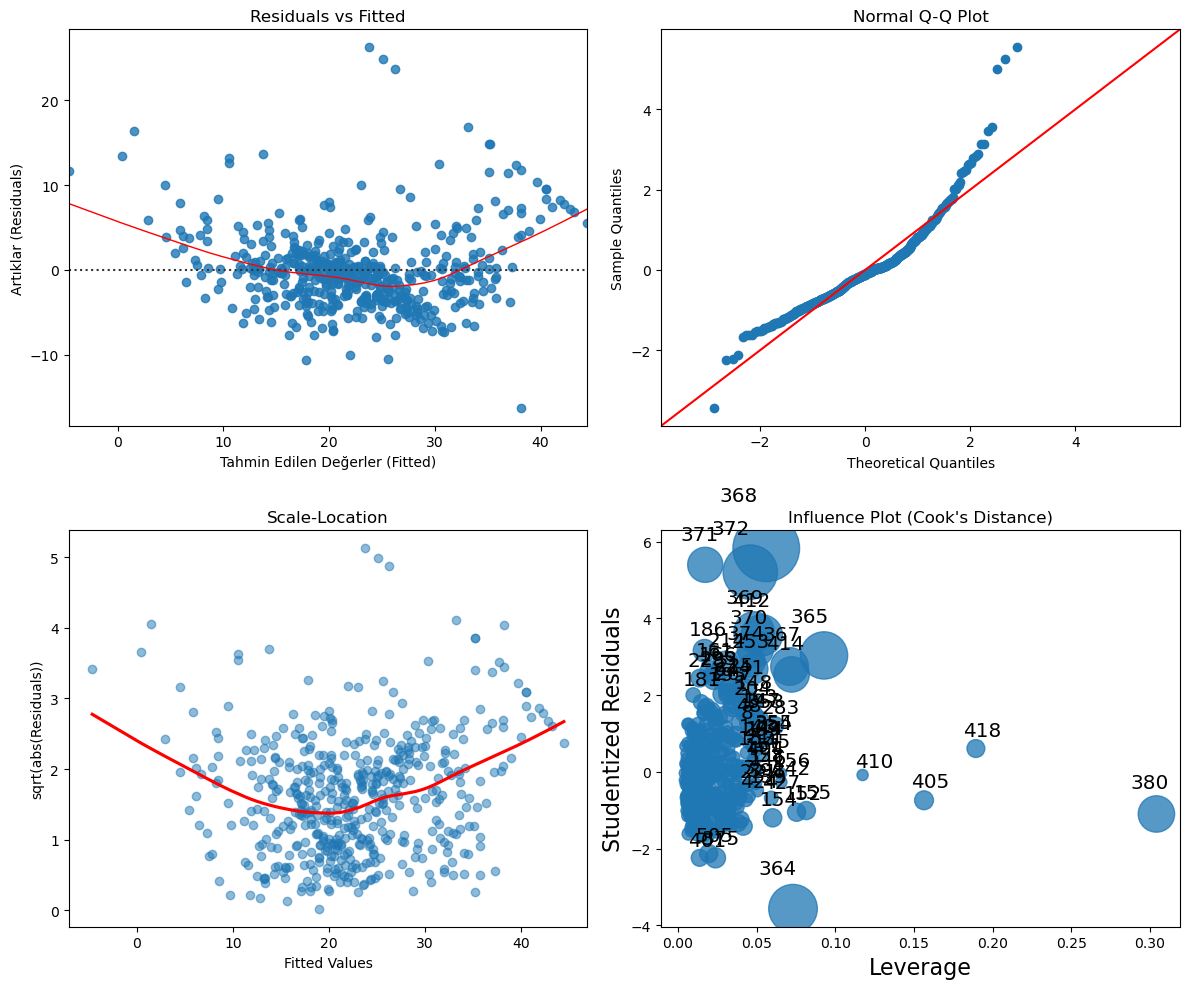

Durbin-Watson Statistics: 1.090
Breusch-Pagan P-Value: 0.0000


In [7]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.residplot(x=fitted_values, y=residuals, lowess=True, 
              line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Tahmin Edilen Değerler (Fitted)')
plt.ylabel('Artıklar (Residuals)')
plt.title('Residuals vs Fitted')

plt.subplot(2, 2, 2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Normal Q-Q Plot')

plt.subplot(2, 2, 3)
plt.scatter(fitted_values, (residuals.abs())**0.5, alpha=0.5)
sns.regplot(x=fitted_values, y=(residuals.abs())**0.5, 
            scatter=False, ci=None, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted Values')
plt.ylabel('sqrt(abs(Residuals))')
plt.title('Scale-Location')

plt.subplot(2, 2, 4)
sm.graphics.influence_plot(model, criterion="cooks", ax=plt.gca())
plt.title('Influence Plot (Cook\'s Distance)')

plt.tight_layout()
plt.show()

print(f"Durbin-Watson Statistics: {durbin_watson(residuals):.3f}")

_, p_val, _, _ = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan P-Value: {p_val:.4f}")

In [8]:
y = np.log(data["MEDV"])

X["LSTAT"] = X["LSTAT"] ** 2

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     144.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          7.85e-140
Time:                        21:31:31   Log-Likelihood:                 80.751
No. Observations:                 506   AIC:                            -139.5
Df Residuals:                     495   BIC:                            -93.01
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6585      0.218     16.753      0.000       3.229       4.088
CRIM          -0.0102      0.001     -7.041      0.000      -0.013      -0.007
ZN             0.0011      0.001      1.795      0.073   -9.96e-05       0.002
CHAS           0.1256      0.037      3.353      0.001       0.052       0.199
NOX           -1.0644      0.149     -7.127      0.000      -1.358      -0.771
RM             0.1441      0.017      8.506      0.000       0.111       0.177
DIS           -0.0483      0.008     -5.917      0.000      -0.064      -0.032
RAD            0.0051      0.002      2.891      0.004       0.002       0.009
PTRATIO       -0.0457      0.006     -8.173      0.000      -0.057      -0.035
B              0.0005      0.000      4.414      0.000       0.000       0.001
LSTAT         -0.0006   5.61e-05    -10.930      0.000      -0.001      -0.001
==============================================================================
Omnibus:                       80.783   Durbin-Watson:                   1.042
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              326.909
Skew:                           0.652   Prob(JB):                     1.03e-71
Kurtosis:                       6.715   Cond. No.                     1.14e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.14e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [9]:
X = X.drop(["ZN"], axis = 1)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     159.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          2.98e-140
Time:                        21:31:31   Log-Likelihood:                 79.110
No. Observations:                 506   AIC:                            -138.2
Df Residuals:                     496   BIC:                            -95.95
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6766      0.219     16.816      0.000       3.247       4.106
CRIM          -0.0100      0.001     -6.912      0.000      -0.013      -0.007
CHAS           0.1245      0.038      3.315      0.001       0.051       0.198
NOX           -1.0835      0.149     -7.257      0.000      -1.377      -0.790
RM             0.1490      0.017      8.887      0.000       0.116       0.182
DIS           -0.0410      0.007     -5.779      0.000      -0.055      -0.027
RAD            0.0055      0.002      3.136      0.002       0.002       0.009
PTRATIO       -0.0490      0.005     -9.239      0.000      -0.059      -0.039
B              0.0005      0.000      4.416      0.000       0.000       0.001
LSTAT         -0.0006   5.61e-05    -10.800      0.000      -0.001      -0.000
==============================================================================
Omnibus:                       84.261   Durbin-Watson:                   1.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              340.106
Skew:                           0.686   Prob(JB):                     1.40e-74
Kurtosis:                       6.775   Cond. No.                     1.14e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.14e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

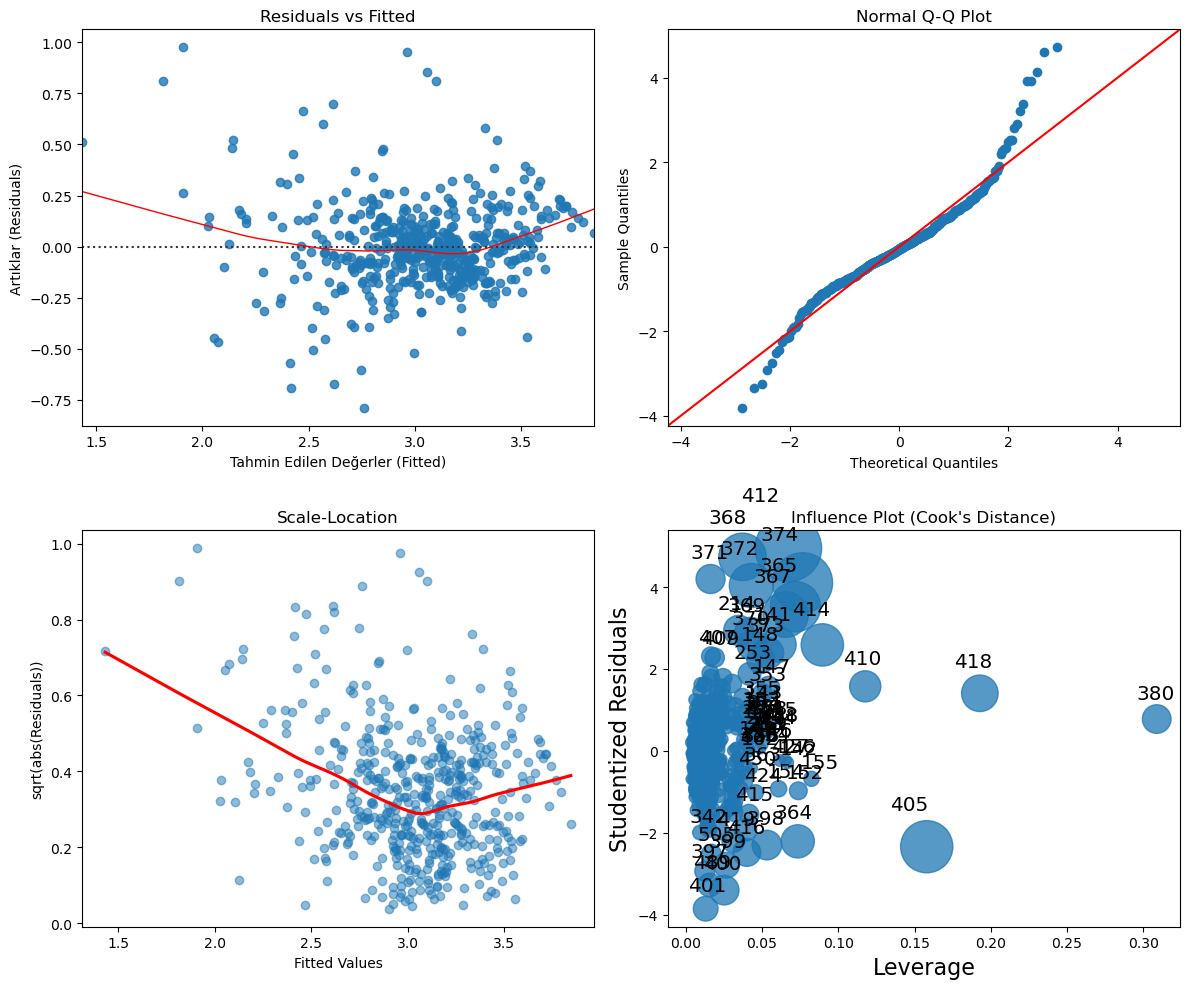

Durbin-Watson Statistics: 1.033
Breusch-Pagan P-Value: 0.0000


In [10]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.residplot(x=fitted_values, y=residuals, lowess=True, 
              line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Tahmin Edilen Değerler (Fitted)')
plt.ylabel('Artıklar (Residuals)')
plt.title('Residuals vs Fitted')

plt.subplot(2, 2, 2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Normal Q-Q Plot')

plt.subplot(2, 2, 3)
plt.scatter(fitted_values, (residuals.abs())**0.5, alpha=0.5)
sns.regplot(x=fitted_values, y=(residuals.abs())**0.5, 
            scatter=False, ci=None, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted Values')
plt.ylabel('sqrt(abs(Residuals))')
plt.title('Scale-Location')

plt.subplot(2, 2, 4)
sm.graphics.influence_plot(model, criterion="cooks", ax=plt.gca())
plt.title('Influence Plot (Cook\'s Distance)')

plt.tight_layout()
plt.show()

print(f"Durbin-Watson Statistics: {durbin_watson(residuals):.3f}")

_, p_val, _, _ = het_breuschpagan(residuals, model.model.exog)
print(f"Breusch-Pagan P-Value: {p_val:.4f}")